In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None) #displays all columns of a dataset without truncating

In [3]:
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv(r"C:\Users\Sai Yedlapalli\Downloads\lending_club_loan_two.csv", encoding="latin-1")

In [5]:
meta_data = pd.read_csv(r"C:\Users\Sai Yedlapalli\Downloads\lending_club_info.csv", encoding = "latin-1")

In [6]:
meta_data

,LoanStatNew,Description
0,loan_amnt,The listed amount of the loan applied for by t...
1,term,The number of payments on the loan. Values are...
2,int_rate,Interest Rate on the loan
3,installment,The monthly payment owed by the borrower if th...
4,grade,LC assigned loan grade
5,sub_grade,LC assigned loan subgrade
6,emp_title,The job title supplied by the Borrower when ap...
7,emp_length,Employment length in years. Possible values ar...
8,home_ownership,The home ownership status provided by the borr...
9,annual_inc,The self-reported annual income provided by th...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394275 non-null  object 
 15  

In [8]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [9]:
df['loan_status'].value_counts()*100/len(df) #needs rebalancing before training

Fully Paid     80.387092
Charged Off    19.612908
Name: loan_status, dtype: float64

The Targert Variable is 'loan_status'. 
It is important to understand the the target variable's relationship with independent variables(Features)(both categorical and numerical).
We can use various plots from seaborn to examine these relationships

<Axes: xlabel='loan_amnt', ylabel='Count'>

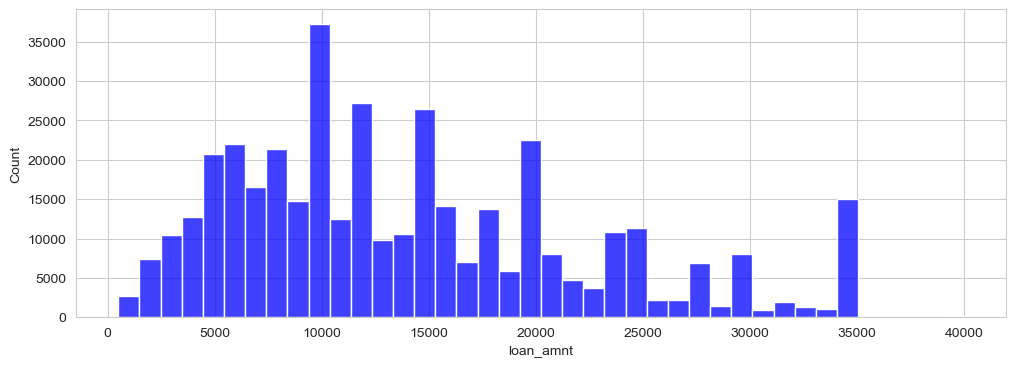

In [10]:
#Data Exploratory Analysis
plt.figure(figsize = (12,4))
sns.histplot(df["loan_amnt"],bins=40,color = "blue")

<Axes: >

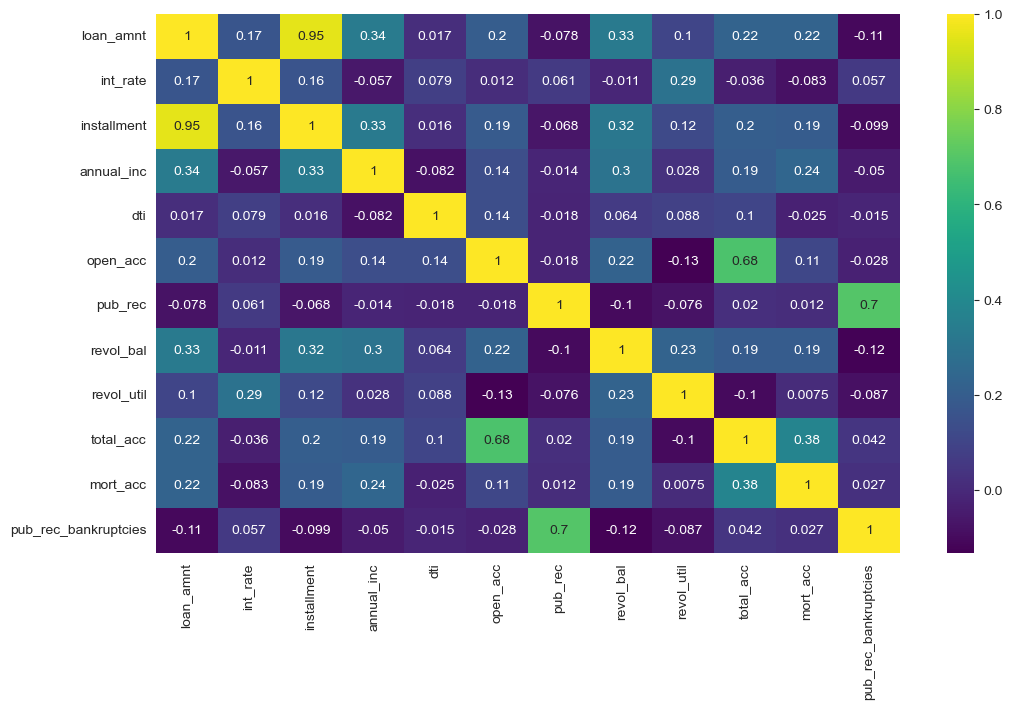

In [11]:
# This heatmap shows the correlation between the numerical variables
plt.figure(figsize = (12,7))
numeric_df = df.select_dtypes(include = ["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot = True, cmap = "viridis")

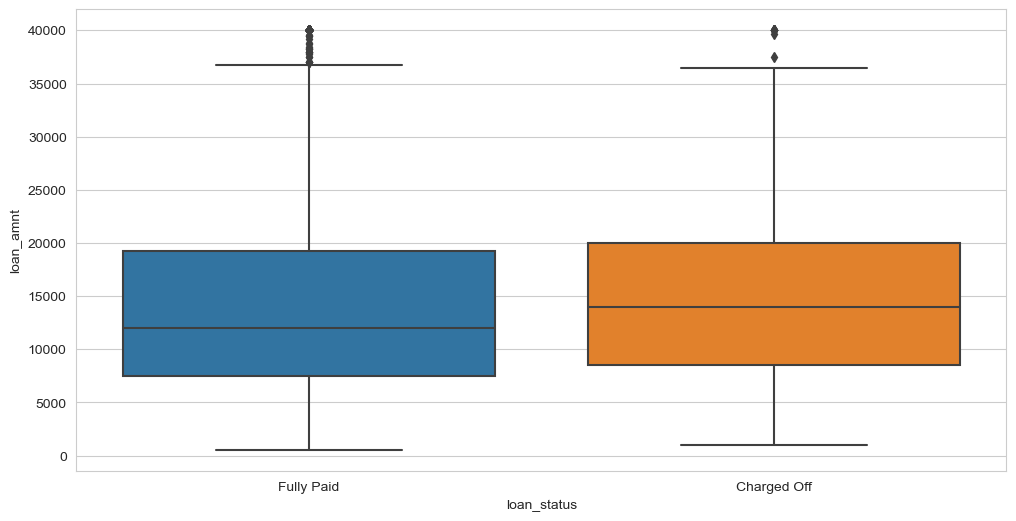

In [12]:
#examine the relationship between 'loan_amnt' and 'loan_status'
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y = 'loan_amnt', data = df)
plt.show()

<Axes: xlabel='grade', ylabel='count'>

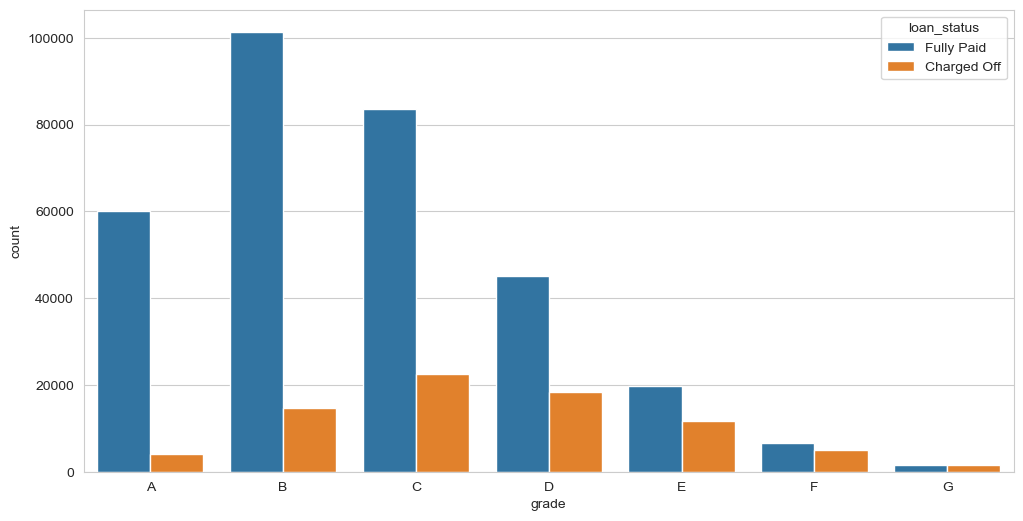

In [13]:
#relationship between 'loan_status' and 'grade'
plt.figure(figsize = (12,6))
grade_order = ['A','B','C','D','E','F','G']
sns.countplot(x='grade', hue='loan_status', data=df, order=grade_order)

In [14]:
#proportion loan_status for 'grade A' loans
df[df['grade']=='A'].groupby("loan_status")['grade'].count()/len(df[df['grade']=='A'])

loan_status
Charged Off    0.062879
Fully Paid     0.937121
Name: grade, dtype: float64

In [15]:
#proportion loan_status for 'grade B' loans
df[df['grade']=='B'].groupby("loan_status")['grade'].count()/len(df[df['grade']=='B']) 

loan_status
Charged Off    0.12573
Fully Paid     0.87427
Name: grade, dtype: float64

In [16]:
#proportion loan_status for 'grade C' loans
df[df['grade']=='C'].groupby("loan_status")['grade'].count()/len(df[df['grade']=='C'])

loan_status
Charged Off    0.211809
Fully Paid     0.788191
Name: grade, dtype: float64

In [17]:
#proportion loan_status for 'grade D' loans
df[df['grade']=='D'].groupby("loan_status")['grade'].count()/len(df[df['grade']=='D'])

loan_status
Charged Off    0.288678
Fully Paid     0.711322
Name: grade, dtype: float64

In [18]:
#proportion loan_status for 'grade G' loans
df[df['grade']=='G'].groupby("loan_status")['grade'].count()/len(df[df['grade']=='G'])

loan_status
Charged Off    0.478389
Fully Paid     0.521611
Name: grade, dtype: float64

We can see from the above calculations that as the grade worsens the %charge-off increases

In [19]:
#convert 'loan_status' to numerical

df['loan_status']=df['loan_status'].apply(lambda x:1 if x=='Fully Paid' else 0)

In [20]:
df["term"] = df["term"].apply(lambda x: int(str(x)[:3]))

In [21]:
df.select_dtypes(["object"]).columns

Index(['grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'verification_status', 'issue_d', 'purpose', 'title',
       'earliest_cr_line', 'initial_list_status', 'application_type',
       'address'],
      dtype='object')

In [22]:
df.drop('sub_grade', axis = 1, inplace = True)

In [23]:
df.drop('emp_title', axis = 1, inplace = True)

In [24]:
df.select_dtypes(["object"]).columns

Index(['grade', 'emp_length', 'home_ownership', 'verification_status',
       'issue_d', 'purpose', 'title', 'earliest_cr_line',
       'initial_list_status', 'application_type', 'address'],
      dtype='object')

In [25]:
#emp_length variable - Analysis
df['emp_length'].unique()

array(['10+ years', '4 years', '< 1 year', '6 years', '9 years',
       '2 years', '3 years', '8 years', '7 years', '5 years', '1 year',
       nan], dtype=object)

In [26]:
#slice the emp_length variable to contain strings
df['emp_length'] = df['emp_length'].replace({"< 1 year": "0", "10+ years": "10"})
df['emp_length'] = df['emp_length'].astype(str).str.extract(r"(\d+)").astype(float)
df['emp_length'].unique()

array([10.,  4.,  0.,  6.,  9.,  2.,  3.,  8.,  7.,  5.,  1., nan])

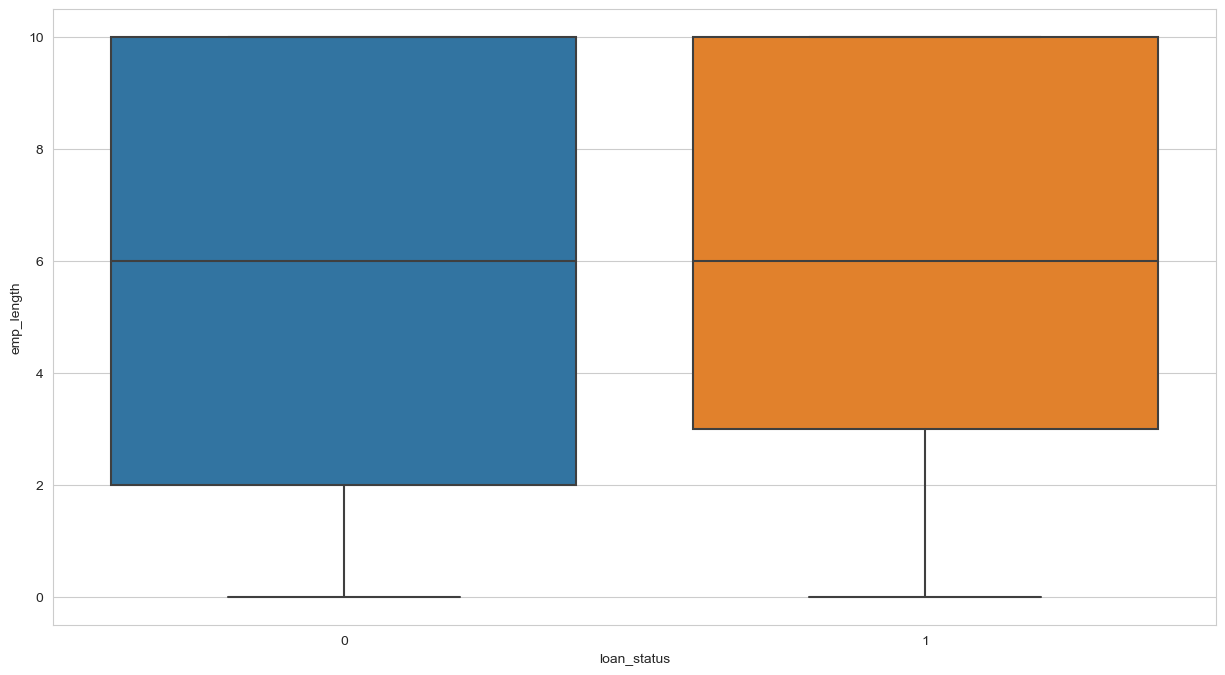

In [27]:
plt.figure(figsize = (15,8))
sns.boxplot(x = df['loan_status'], y = df['emp_length'], data = df)
plt.show()

In [28]:
#since emp_length has no significant relationship to loan_status, drop the emp_length column
df.drop('emp_length', axis = 1, inplace = True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  int64  
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   home_ownership        396030 non-null  object 
 6   annual_inc            396030 non-null  float64
 7   verification_status   396030 non-null  object 
 8   issue_d               396030 non-null  object 
 9   loan_status           396030 non-null  int64  
 10  purpose               396030 non-null  object 
 11  title                 394275 non-null  object 
 12  dti                   396030 non-null  float64
 13  earliest_cr_line      396030 non-null  object 
 14  open_acc              396030 non-null  float64
 15  

In [30]:
df['mort_acc'].isnull().sum()

37795

In [31]:
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].mean()) #replace null values with the mean (avg. no. of mortgage accounts)

In [32]:
df.isnull().sum()/len(df)

loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
installment             0.000000
grade                   0.000000
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.004431
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.000697
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                0.000000
pub_rec_bankruptcies    0.001351
address                 0.000000
dtype: float64

In [33]:
df.dropna(inplace = True)#drop the remaining null values from all columns as the proportions of null values are insignificant

In [34]:
df['title'].nunique()

48472

In [35]:
#'title' column has a large number of unique values making it very difficult to encode
df.drop("title", axis = 1, inplace = True)

In [61]:
df["home_ownership"].value_counts()

1    197110
0    158770
2     37443
3       142
Name: home_ownership, dtype: int64

In [37]:
df["home_ownership"] = df["home_ownership"].replace(["NONE","ANY"],"OTHER")

In [38]:
df["home_ownership"].value_counts()

MORTGAGE    197110
RENT        158770
OWN          37443
OTHER          142
Name: home_ownership, dtype: int64

In [39]:
df["address"].head()

0       0174 Michelle Gateway\nMendozaberg, OK 22690
1    1076 Carney Fort Apt. 347\nLoganmouth, SD 05113
2    87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113
3              823 Reid Ford\nDelacruzside, MA 00813
4               679 Luna Roads\nGreggshire, VA 11650
Name: address, dtype: object

In [40]:
df["zip"] = df["address"].apply(lambda x:x[-5:]) #extracting the zip-code from address

In [41]:
df["zip"].head()

0    22690
1    05113
2    05113
3    00813
4    11650
Name: zip, dtype: object

In [42]:
df.drop("address", axis=1, inplace = True)

In [43]:
df["earliest_cr_line"]=df["earliest_cr_line"].apply(lambda x:x[-4:]) #comsidering only the year instead of the entire column

In [44]:
df["pub_rec"] = df["pub_rec"].apply(lambda x: 0 if x==0 else 1) #keep pub_rec as 0 only if x is 0, rest could be set to 1 to indentify risky customers

Ordinal Encoding - Convert categorical columns into numerical

In [45]:
cols = df.select_dtypes(["object"]).columns

In [46]:
def ordinal_mapper(data,var):
    ordinal_map = {k:i for i,k in enumerate(data[var].unique(),0)}
    data[var] = data[var].map(ordinal_map)

In [47]:
for var in cols:
    ordinal_mapper(df,var)

In [48]:
df[cols].head()

,grade,home_ownership,verification_status,issue_d,purpose,earliest_cr_line,initial_list_status,application_type,zip
0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,1,1,1,0,1
2,0,0,1,0,2,2,1,0,1
3,1,0,0,1,2,3,1,0,2
4,2,1,2,2,2,4,1,0,3


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X = df.drop("loan_status", axis = 1)
Y = df["loan_status"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.33, random_state =42)

In [57]:
from sklearn.preprocessing import MinMaxScaler

In [58]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
import logging
from tensorflow.keras.callbacks import EarlyStopping

In [67]:
#creating model
model = Sequential()

#adding layer
model.add(Dense(78,activation="relu"))
model.add(Dropout(0.2))


model.add(Dense(39,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(19,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(19,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=1, activation="sigmoid"))

model.compile(loss="binary_crossentropy", optimizer="adam")
#parameters for early stopping
early_stop=EarlyStopping(monitor="val_loss", mode="min", verbose=1, patience=5)


In [68]:
#running the model
model.fit(x=X_train, y=Y_train, epochs=25,batch_size=256, validation_data=(X_test, Y_test), callbacks=[early_stop])

Epoch 1/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.4996 - val_loss: 0.3776
Epoch 2/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3836 - val_loss: 0.3693
Epoch 3/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3730 - val_loss: 0.3611
Epoch 4/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3670 - val_loss: 0.3417
Epoch 5/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3465 - val_loss: 0.2980
Epoch 6/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3084 - val_loss: 0.2790
Epoch 7/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2891 - val_loss: 0.2682
Epoch 8/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2831 - val_loss: 0.2673
Epoch 9/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2787 - val_loss: 0.2645
Epoch 10/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2742 - val_loss: 0.2655
Epoch 11/25
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2726 - val_loss: 0.2643
Epoch 12/25
1030/1030 ━━━━━━━━

<Axes: >

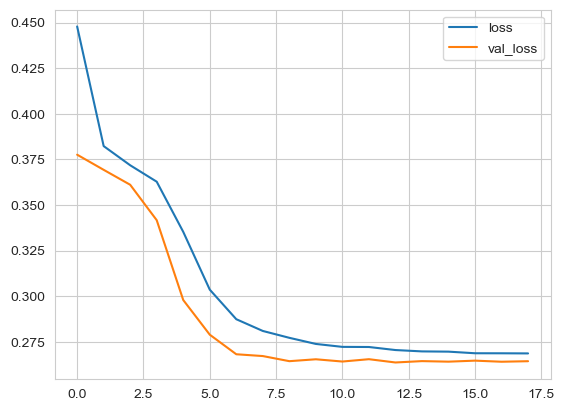

In [69]:
#plotting the losses
loss = pd.DataFrame(model.history.history)

loss.plot()

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
pred_probs = model.predict(X_test)
predict = (pred_probs > 0.5).astype("int32")

print(classification_report(Y_test,predict))
print(confusion_matrix(Y_test,predict))
print(roc_auc_score(Y_test,predict))

4058/4058 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
              precision    recall  f1-score   support

           0       1.00      0.43      0.60     25668
           1       0.88      1.00      0.93    104176

    accuracy                           0.89    129844
   macro avg       0.94      0.71      0.77    129844
weighted avg       0.90      0.89      0.87    129844

[[ 10947  14721]
 [     2 104174]]
0.7132325700980446


In [71]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [72]:
algo = [LinearSVC(),
        LogisticRegression(random_state=0, solver = "lbfgs", max_iter=1000),
        GaussianNB(),
        RandomForestClassifier(random_state=0, n_estimators=10)]

In [73]:
def model_clf(x):
    cl=x
    cl.fit(X_train, Y_train)
    predict = cl.predict(X_test)
    print(classification_report(Y_test,predict))
    print("\nConfusion Matrix:\n", confusion_matrix(Y_test, predict))
    print("\nROC-AUC Score:\n", roc_auc_score(Y_test, predict))

In [74]:
for alg in algo:
    model_clf(alg)

C:\Users\Thushara Chowdary\anaconda\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.73      0.10      0.17     25668
           1       0.82      0.99      0.90    104176

    accuracy                           0.81    129844
   macro avg       0.77      0.54      0.53    129844
weighted avg       0.80      0.81      0.75    129844


Confusion Matrix:
 [[  2496  23172]
 [   932 103244]]

ROC-AUC Score:
 0.5441476516635385
              precision    recall  f1-score   support

           0       0.66      0.17      0.27     25668
           1       0.83      0.98      0.90    104176

    accuracy                           0.82    129844
   macro avg       0.74      0.57      0.58    129844
weighted avg       0.79      0.82      0.77    129844


Confusion Matrix:
 [[  4367  21301]
 [  2262 101914]]

ROC-AUC Score:
 0.574210382259801
              precision    recall  f1-score   support

           0       0.52      0.21      0.29     25668
           1       0.83      0.95      0.89    104176

 